In [3]:
import pandas as pd

try:
    df = pd.read_csv(
        "data/20210703_greenhouse_data.csv",
        sep=";"
    )

    print("DATASET LOADED SUCCESSFULLY!\n")

    display(df.head())

    print("\nCOLUMN NAMES:")
    print(df.columns)

except Exception as e:
    print("ERROR:")
    print(e)

DATASET LOADED SUCCESSFULLY!



,id,greenhous_temperature_celsius,greenhouse_humidity_percentage,greenhouse_illuminance_lux,online_temperature_celsius,online_humidity_percentage,greenhouse_total_volatile_organic_compounds_ppb,greenhouse_equivalent_co2_ppm,created
0,361496,"13,22325653500027","68,05557590060764",0,"7,300000190734863",89.0,370,"1080,4444444444443",2021-03-03 20:10:04
1,361543,"13,149614620208741","68,27115402221679",0,"6,300000190734863",91.0,"380,3","1068,1",2021-03-03 20:20:03
2,361595,"13,094339275360108","68,40222930908203",0,"6,300000190734863",91.0,371,"1022,7",2021-03-03 20:30:04
3,361647,"12,989395236968994","68,48355865478516",0,"5,300000190734863",94.0,363,"995,6",2021-03-03 20:40:03
4,361699,"12,901927100287544","68,55691952175565",0,"5,400000095367432",94.0,350,"960,8888888888889",2021-03-03 20:50:05



COLUMN NAMES:
Index(['id', 'greenhous_temperature_celsius', 'greenhouse_humidity_percentage',
       'greenhouse_illuminance_lux', 'online_temperature_celsius',
       'online_humidity_percentage',
       'greenhouse_total_volatile_organic_compounds_ppb',
       'greenhouse_equivalent_co2_ppm', 'created'],
      dtype='object')


In [4]:
import numpy as np

# Convert columns with comma decimals into float
columns_to_convert = [
    'greenhous_temperature_celsius',
    'greenhouse_humidity_percentage',
    'online_temperature_celsius',
    'online_humidity_percentage',
    'greenhouse_equivalent_co2_ppm'
]

for col in columns_to_convert:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert created column into datetime
df['created'] = pd.to_datetime(df['created'])

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

print("DATA CLEANING COMPLETE!\n")

print(df.dtypes)

display(df.head())

DATA CLEANING COMPLETE!

id                                                          int64
greenhous_temperature_celsius                             float64
greenhouse_humidity_percentage                            float64
greenhouse_illuminance_lux                                 object
online_temperature_celsius                                float64
online_humidity_percentage                                float64
greenhouse_total_volatile_organic_compounds_ppb            object
greenhouse_equivalent_co2_ppm                             float64
created                                            datetime64[ns]
dtype: object


,id,greenhous_temperature_celsius,greenhouse_humidity_percentage,greenhouse_illuminance_lux,online_temperature_celsius,online_humidity_percentage,greenhouse_total_volatile_organic_compounds_ppb,greenhouse_equivalent_co2_ppm,created
0,361496,13.223257,68.055576,0,7.3,89.0,370,1080.444444,2021-03-03 20:10:04
1,361543,13.149615,68.271154,0,6.3,91.0,"380,3",1068.100000,2021-03-03 20:20:03
2,361595,13.094339,68.402229,0,6.3,91.0,371,1022.700000,2021-03-03 20:30:04
3,361647,12.989395,68.483559,0,5.3,94.0,363,995.600000,2021-03-03 20:40:03
4,361699,12.901927,68.556920,0,5.4,94.0,350,960.888889,2021-03-03 20:50:05


In [5]:
# Convert remaining object columns into numeric

remaining_columns = [
    'greenhouse_illuminance_lux',
    'greenhouse_total_volatile_organic_compounds_ppb'
]

for col in remaining_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove possible null values after conversion
df.dropna(inplace=True)

print(df.dtypes)

id                                                          int64
greenhous_temperature_celsius                             float64
greenhouse_humidity_percentage                            float64
greenhouse_illuminance_lux                                float64
online_temperature_celsius                                float64
online_humidity_percentage                                float64
greenhouse_total_volatile_organic_compounds_ppb           float64
greenhouse_equivalent_co2_ppm                             float64
created                                            datetime64[ns]
dtype: object


In [6]:
filtered_df = df[
    (df['greenhous_temperature_celsius'] > 13) &
    (df['greenhouse_humidity_percentage'] < 70) &
    (df['created'].dt.hour >= 12) &
    (df['created'].dt.hour <= 17)
]

print("FILTERED DATASET SHAPE:")
print(filtered_df.shape)

display(filtered_df.head())

FILTERED DATASET SHAPE:
(4340, 9)


,id,greenhous_temperature_celsius,greenhouse_humidity_percentage,greenhouse_illuminance_lux,online_temperature_celsius,online_humidity_percentage,greenhouse_total_volatile_organic_compounds_ppb,greenhouse_equivalent_co2_ppm,created
95,366311,13.526131,69.109787,2328.900000,4.0,97.0,477.000000,1092.300000,2021-03-04 12:00:06
96,366363,13.742695,69.042038,2667.900000,3.9,97.0,462.600000,1080.800000,2021-03-04 12:10:04
97,366415,13.846838,69.023422,2306.200000,3.9,97.0,471.000000,1093.100000,2021-03-04 12:20:05
98,366467,13.836839,69.063858,1881.555556,4.0,97.0,470.333333,1091.777778,2021-03-04 12:30:05
99,366514,13.740025,69.132675,1590.600000,4.0,97.0,465.500000,1079.300000,2021-03-04 12:40:06


In [7]:
filtered_df.to_csv(
    "data/dataset_cleaned.csv",
    index=False
)

print("CLEANED DATASET SAVED!")

CLEANED DATASET SAVED!


In [8]:
import numpy as np

temperature = filtered_df['greenhous_temperature_celsius']

mean_temp = np.mean(temperature)
median_temp = np.median(temperature)
std_temp = np.std(temperature)
variance_temp = np.var(temperature)

print("TEMPERATURE STATISTICS\n")

print(f"Mean: {mean_temp}")
print(f"Median: {median_temp}")
print(f"Standard Deviation: {std_temp}")
print(f"Variance: {variance_temp}")

TEMPERATURE STATISTICS

Mean: 37.00352766382722
Median: 34.32189538743761
Standard Deviation: 14.318436399222316
Variance: 205.01762091857452


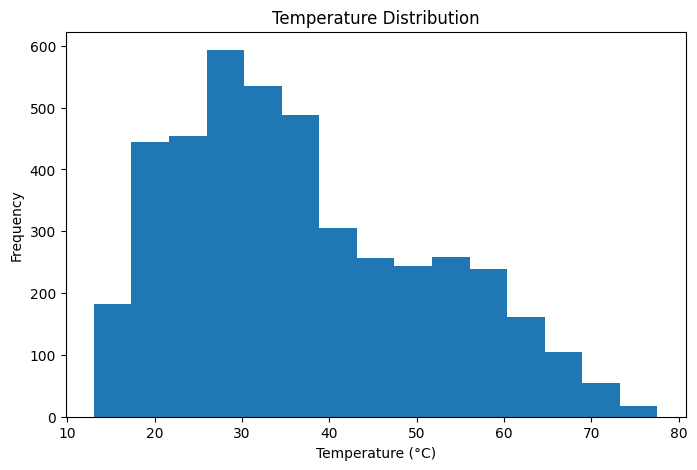

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    filtered_df['greenhous_temperature_celsius'],
    bins=15
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.savefig("outputs/temperature_histogram.png")

plt.show()

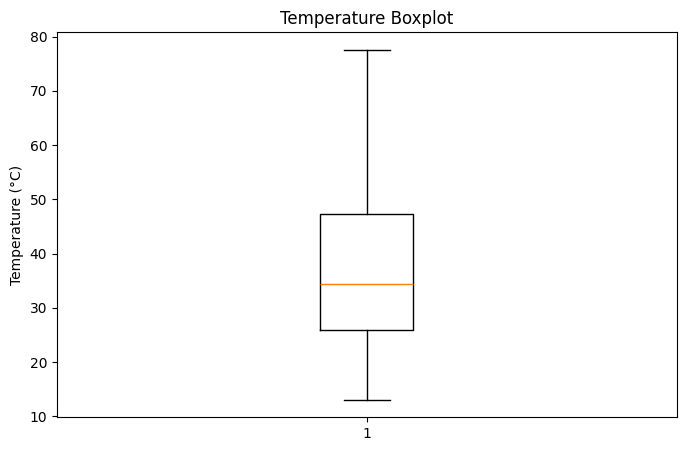

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(
    filtered_df['greenhous_temperature_celsius']
)

plt.title("Temperature Boxplot")

plt.ylabel("Temperature (°C)")

plt.savefig("outputs/temperature_boxplot.png")

plt.show()

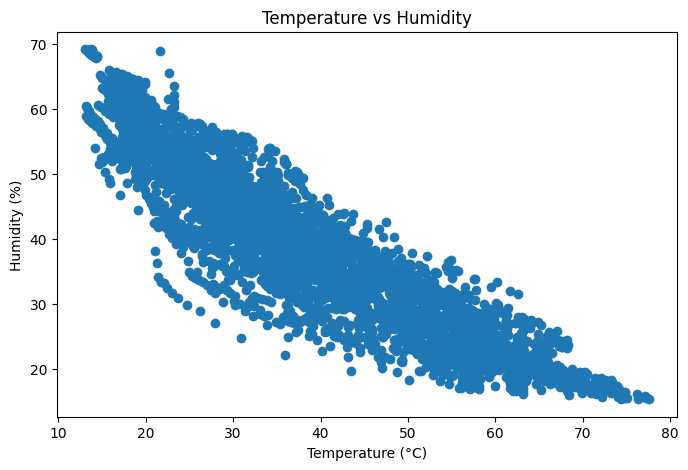

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    filtered_df['greenhous_temperature_celsius'],
    filtered_df['greenhouse_humidity_percentage']
)

plt.title("Temperature vs Humidity")

plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")

plt.savefig("outputs/temperature_vs_humidity.png")

plt.show()

In [13]:
correlation = filtered_df[
    [
        'greenhous_temperature_celsius',
        'greenhouse_humidity_percentage'
    ]
].corr()

print(correlation)

                                greenhous_temperature_celsius  \
greenhous_temperature_celsius                        1.000000   
greenhouse_humidity_percentage                      -0.910159   

                                greenhouse_humidity_percentage  
greenhous_temperature_celsius                        -0.910159  
greenhouse_humidity_percentage                        1.000000  


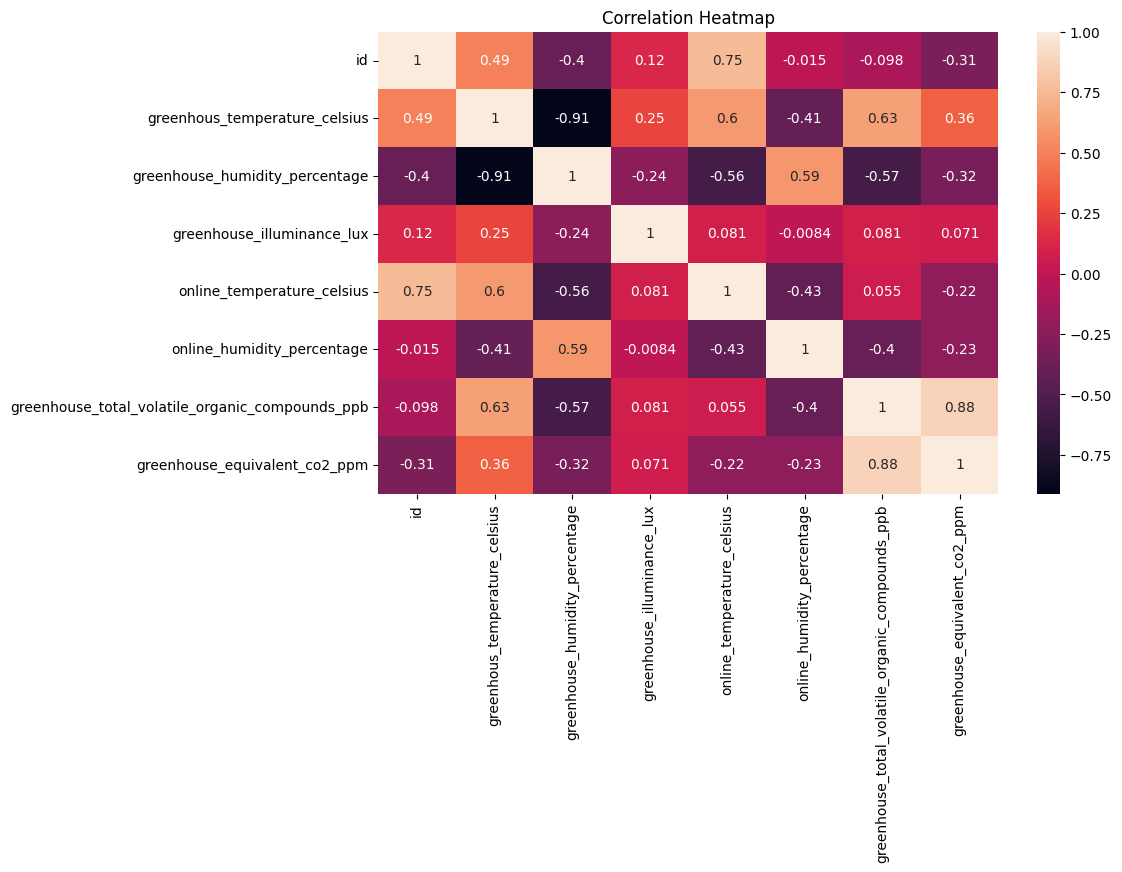

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = filtered_df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title("Correlation Heatmap")

plt.savefig("outputs/correlation_heatmap.png")

plt.show()

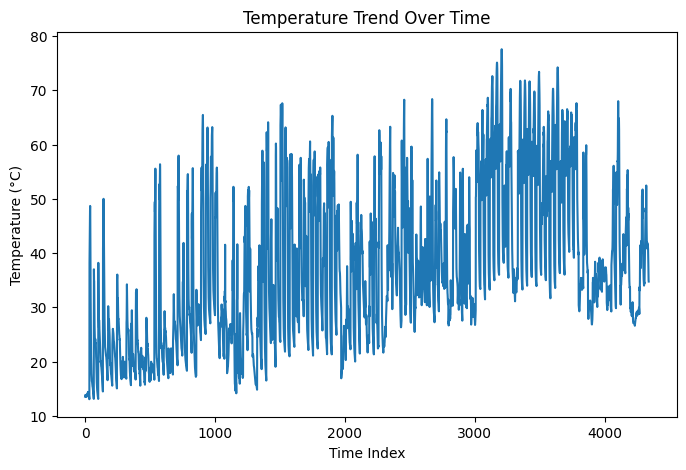

In [15]:
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

x = []
y = []

def animate(i):

    x.append(i)

    y.append(
        filtered_df[
            'greenhous_temperature_celsius'
        ].iloc[i]
    )

    ax.clear()

    ax.plot(x, y)

    ax.set_title("Temperature Trend Over Time")
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Temperature (°C)")

animation = FuncAnimation(
    fig,
    animate,
    frames=len(filtered_df),
    interval=50
)

animation.save(
    "outputs/temperature_animation.gif",
    writer='pillow'
)

plt.show()


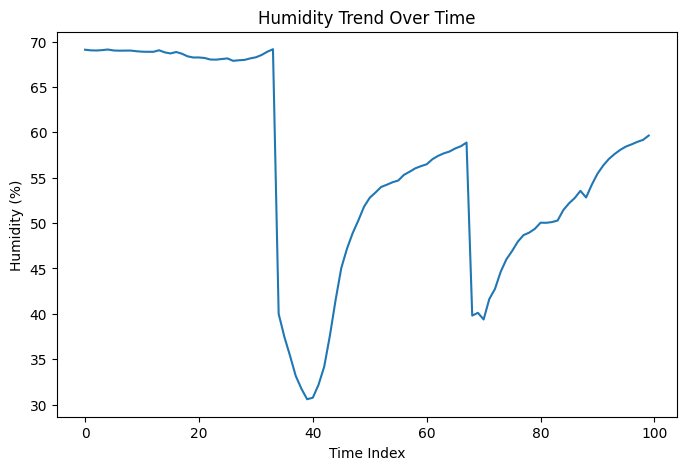

In [16]:
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

x = []
y = []

def animate(i):

    x.append(i)

    y.append(
        filtered_df[
            'greenhouse_humidity_percentage'
        ].iloc[i]
    )

    ax.clear()

    ax.plot(x, y)

    ax.set_title("Humidity Trend Over Time")
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Humidity (%)")

animation = FuncAnimation(
    fig,
    animate,
    frames=100,
    interval=50
)

animation.save(
    "outputs/humidity_animation.gif",
    writer='pillow'
)

plt.show()